# Together

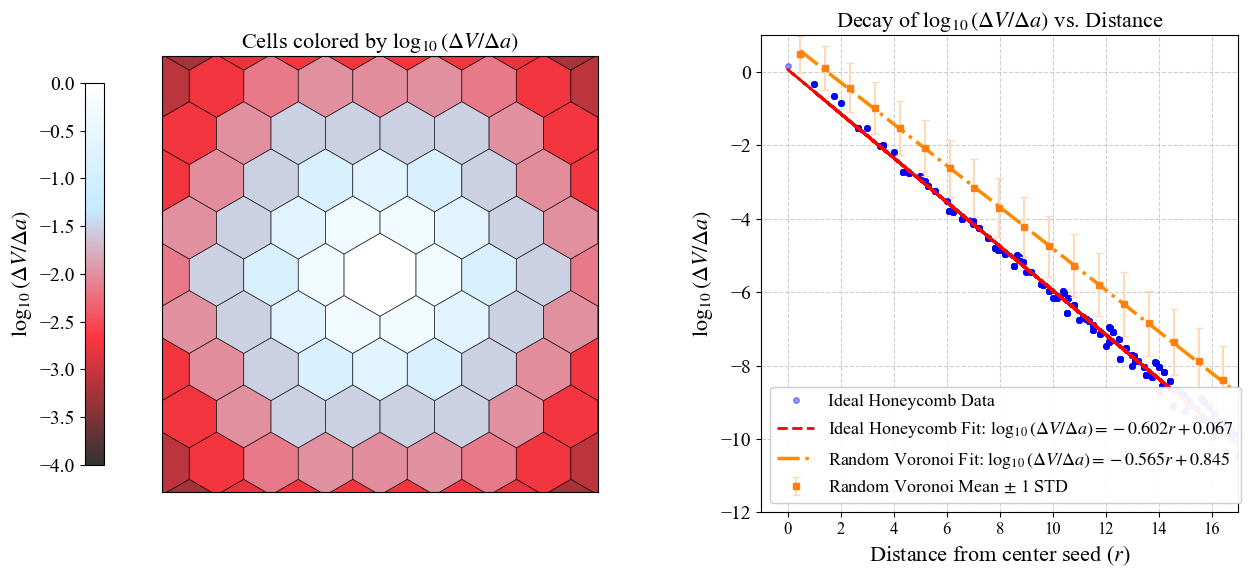

Decay constant (Single Run slope): -0.6017846790594292
Decay constant (Ensemble slope): -0.5654401314096587


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import Voronoi
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from scipy.stats import linregress

# ==========================================
# 1) Setup & Publication Styling
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.titlesize': 18
})

# ----------------------------
# Geometry helpers
# ----------------------------

def make_triangular_lattice_squareish(N_target=None, a=1.0, prefer_more=True):
    root3 = np.sqrt(3.0)
    if N_target is None:
        N_target = 1200

    ny_est = int(max(1, round(np.sqrt((2.0 / root3) * N_target))))
    candidates = []
    for ny in range(max(1, ny_est - 200), ny_est + 201):
        nx = max(1, int(round((root3 / 2.0) * ny)))
        N = nx * ny
        if prefer_more and N < N_target:
            nx2 = int(np.ceil(N_target / ny))
            nx2 = max(nx2, 1)
            N2 = nx2 * ny
            nx, N = nx2, N2
        elif (not prefer_more) and N > N_target:
            nx2 = int(np.floor(N_target / ny))
            nx2 = max(nx2, 1)
            N2 = nx2 * ny
            nx, N = nx2, N2

        if N <= 0:
            continue

        Lx = nx * a
        Ly = ny * (root3 / 2.0) * a
        aspect = max(Lx, Ly) / min(Lx, Ly)
        cost = (aspect - 1.0)**2 + 1e-6 * abs(N - N_target)
        candidates.append((cost, nx, ny, N, Lx, Ly))

    if not candidates:
        raise RuntimeError("Could not find suitable (nx, ny).")

    _, nx, ny, N, Lx, Ly = min(candidates, key=lambda t: t[0])

    pts = np.zeros((N, 2), float)
    idx = 0
    for j in range(ny):
        y = j * (root3 / 2.0) * a
        xoff = 0.5 * a if (j % 2 == 1) else 0.0
        for i in range(nx):
            x = i * a + xoff
            pts[idx] = (x, y)
            idx += 1

    assert idx == N
    return pts, Lx, Ly, nx, ny, N


def non_voronoiness_per_seed(
    central_seed_neighbors, central_seed_vertices, vertices_coords,
    final_coords, N_central, eps=1e-12
):
    out = np.full(N_central, np.nan, dtype=float)
    for n in range(N_central):
        ratios = []
        for (rv, m) in zip(central_seed_vertices[n], central_seed_neighbors[n]):
            if len(rv) == 2 and rv[0] >= 0 and rv[1] >= 0:
                p0 = vertices_coords[rv[0]]
                p1 = vertices_coords[rv[1]]
                mf = final_coords[m]
                nf = final_coords[n]
                r = reflect_point_across_line(p0, p1, mf)
                denom = np.linalg.norm(r - mf)
                num = np.linalg.norm(r - nf)
                ratios.append(num / denom)
        if ratios:
            out[n] = float(np.mean(ratios))
    return out


def reflect_point_across_line(p0, p1, p):
    p0 = np.asarray(p0, float)
    p1 = np.asarray(p1, float)
    p  = np.asarray(p,  float)
    v = p1 - p0
    denom = v @ v
    if denom == 0:
        raise ValueError("p0 and p1 must be distinct to define a line.")
    t = ((p - p0) @ v) / denom       
    f = p0 + t * v                   
    return 2 * f - p                  


def polygon_centroid(pts):
    if len(pts) == 0:
        return np.array([np.nan, np.nan], float)
    return np.mean(pts, axis=0)


# ----------------------------
# Periodic point set
# ----------------------------
def build_periodic_images(central_coords, Lx, Ly):
    N = central_coords.shape[0]
    mx_left  = central_coords[:, 0] >  Lx / 2
    mx_right = central_coords[:, 0] <  Lx / 2
    my_down  = central_coords[:, 1] >  Ly / 2
    my_up    = central_coords[:, 1] <  Ly / 2

    blocks = [central_coords]
    block_ids = [np.arange(N)]
    shifts = [np.zeros_like(central_coords)]

    left_idx  = np.where(mx_left)[0]
    right_idx = np.where(mx_right)[0]
    blocks += [central_coords[left_idx]  + np.array([-Lx, 0.0]),
               central_coords[right_idx] + np.array([+Lx, 0.0])]
    block_ids += [left_idx, right_idx]
    shifts += [np.tile([-Lx, 0.0], (len(left_idx), 1)),
               np.tile([+Lx, 0.0], (len(right_idx), 1))]

    down_idx = np.where(my_down)[0]
    up_idx   = np.where(my_up)[0]
    blocks += [central_coords[down_idx] + np.array([0.0, -Ly]),
               central_coords[up_idx]   + np.array([0.0, +Ly])]
    block_ids += [down_idx, up_idx]
    shifts += [np.tile([0.0, -Ly], (len(down_idx), 1)),
               np.tile([0.0, +Ly], (len(up_idx), 1))]

    ld_idx = np.where(mx_left  & my_down)[0]
    lu_idx = np.where(mx_left  & my_up)[0]
    rd_idx = np.where(mx_right & my_down)[0]
    ru_idx = np.where(mx_right & my_up)[0]
    blocks += [central_coords[ld_idx] + np.array([-Lx, -Ly]),
               central_coords[lu_idx] + np.array([-Lx, +Ly]),
               central_coords[rd_idx] + np.array([+Lx, -Ly]),
               central_coords[ru_idx] + np.array([+Lx, +Ly])]
    block_ids += [ld_idx, lu_idx, rd_idx, ru_idx]
    shifts += [np.tile([-Lx, -Ly], (len(ld_idx), 1)),
               np.tile([-Lx, +Ly], (len(lu_idx), 1)),
               np.tile([+Lx, -Ly], (len(rd_idx), 1)),
               np.tile([+Lx, +Ly], (len(ru_idx), 1))]

    extended_seed_coords = np.vstack(blocks)
    extended_central_indices = np.concatenate(block_ids)
    extended_central_shifts  = np.vstack(shifts)

    return extended_seed_coords, extended_central_indices, extended_central_shifts


# ----------------------------
# Voronoi graph over central seeds
# ----------------------------
def build_central_graph(vor, N_central):
    ridge_points   = vor.ridge_points
    ridge_vertices = vor.ridge_vertices

    central_ridge_indices = [[] for _ in range(N_central)]
    central_seed_neighbors = [[] for _ in range(N_central)]
    central_seed_vertices = [[] for _ in range(N_central)]

    for ridx, (i, j) in enumerate(ridge_points):
        if i < N_central:
            central_ridge_indices[i].append(ridx)
            central_seed_neighbors[i].append(j)
            central_seed_vertices[i].append(ridge_vertices[ridx])
        if j < N_central:
            central_ridge_indices[j].append(ridx)
            central_seed_neighbors[j].append(i)
            central_seed_vertices[j].append(ridge_vertices[ridx])

    return central_ridge_indices, central_seed_neighbors, central_seed_vertices


def cell_centers_from_ridges(central_seed_vertices, vertices_coords, fallback_coords=None):
    centers = []
    for n, ridge_vs in enumerate(central_seed_vertices):
        finite_lists = [rv for rv in ridge_vs if (len(rv) == 2 and rv[0] >= 0 and rv[1] >= 0)]
        unique_idx = np.unique(np.array(finite_lists).ravel()) if finite_lists else np.array([], dtype=int)
        ctr = polygon_centroid(vertices_coords[unique_idx]) if len(unique_idx) else np.array([np.nan, np.nan])
        if (np.isnan(ctr).any()) and fallback_coords is not None:
            ctr = fallback_coords[n]
        centers.append(ctr)
    return np.vstack(centers)


# ----------------------------
# One relaxation-like step via reflections
# ----------------------------
def next_positions(central_seed_neighbors, central_seed_vertices, vertices_coords,
                   initial_coords, N_central, extended_central_indices, extended_central_shifts):
    N_ext = len(extended_central_indices)
    nxt = np.zeros((N_ext, 2), float)

    for n in range(N_central):
        reflecteds = []
        for (rv, m) in zip(central_seed_vertices[n], central_seed_neighbors[n]):
            if len(rv) == 2 and rv[0] >= 0 and rv[1] >= 0:
                p0 = vertices_coords[rv[0]]
                p1 = vertices_coords[rv[1]]
                p2 = initial_coords[m]
                reflecteds.append(reflect_point_across_line(p0, p1, p2))
        if reflecteds:
            nxt[n] = np.mean(reflecteds, axis=0)
        else:
            nxt[n] = initial_coords[n]  

    for m in range(N_central, N_ext):
        n = extended_central_indices[m]
        nxt[m] = nxt[n] + extended_central_shifts[m]

    return nxt


a = 0.01 
scale = 1
n_target = 2000
n_steps = 200
delta = a*scale*2/np.sqrt(3)

tri_pts, Lx, Ly, nx, ny, N_central_seeds = make_triangular_lattice_squareish(
    N_target=n_target,  
    a=scale,          
    prefer_more=True  
)

central_seed_coords = tri_pts

extended_seed_coords, extended_central_indices, extended_central_shifts = \
    build_periodic_images(central_seed_coords, Lx, Ly)
N_extended_seeds = extended_seed_coords.shape[0]

vor = Voronoi(extended_seed_coords)

(central_ridge_indices,
    central_seed_neighbors,
    central_seed_vertices) = build_central_graph(vor, N_central_seeds)

vertices_coords = vor.vertices
initial_coords = np.zeros((N_extended_seeds, 2), float)
initial_coords[:N_central_seeds] = cell_centers_from_ridges(
    central_seed_vertices, vertices_coords, fallback_coords=central_seed_coords
)

box_center = np.array([Lx/2, Ly/2], dtype=float)
central_seed_idx = np.argmin(np.linalg.norm(central_seed_coords - box_center[None, :], axis=1))
central_seed_pos = central_seed_coords[central_seed_idx]
r_idx = vor.point_region[central_seed_idx]
region = vor.regions[r_idx]
cell_vertex_indices = [vi for vi in region if vi != -1]

if len(cell_vertex_indices) == 0:
    raise RuntimeError("Central seed's Voronoi region is unbounded; choose a different seed or ensure interior.")

# We store the vertex shifts separately to exaggerate the plotting later
vertex_shifts = np.zeros_like(vertices_coords)

for vi in cell_vertex_indices:
    v = vertices_coords[vi]
    d = v - central_seed_pos
    nrm = np.linalg.norm(d)
    if nrm > 0:
        shift = (delta * d / nrm)
        vertices_coords[vi] = v + shift
        vertex_shifts[vi] = shift

initial_coords[N_central_seeds:] = (
    initial_coords[extended_central_indices[N_central_seeds:]] +
    extended_central_shifts[N_central_seeds:]
)

current_coords = np.copy(initial_coords)

for t in range(n_steps):
    next_coords = next_positions(
        central_seed_neighbors, central_seed_vertices, vertices_coords,
        current_coords, N_central_seeds, extended_central_indices, extended_central_shifts
    )
    current_coords = next_coords

final_coords = current_coords

nv = non_voronoiness_per_seed(
    central_seed_neighbors, central_seed_vertices, vor.vertices,
    final_coords, N_central_seeds
)

distances = np.linalg.norm(central_seed_coords - central_seed_coords[central_seed_idx], axis=1)
displacements = np.linalg.norm((np.asarray(final_coords) - np.asarray(initial_coords)), axis=1)/a

# ----------------------------
# Build patches with Exaggeration for Plotting
# ----------------------------
visual_exaggeration = 15.0 
plot_vertices = vertices_coords + vertex_shifts * visual_exaggeration

patches, colors = [], []
for i in range(N_central_seeds):
    r_idx = vor.point_region[i]
    region = vor.regions[r_idx]
    if not region or -1 in region:   
        continue
    # Use the visually exaggerated vertices instead of the raw vor.vertices
    poly = plot_vertices[region]
    patches.append(Polygon(poly, closed=True))
    colors.append(np.log10(nv[i]/a))            

# ----------------------------
# Fit Single Run Data (0 to 15)
# ----------------------------
min_distance = 0.0
max_distance = 15.0
mask_single = (distances <= max_distance) & (distances >= min_distance)
slope, intercept, r_value, p_value, std_err = linregress(distances[mask_single], np.log10(nv[mask_single]/a))
fit_line = slope * distances + intercept
fit_equation = fr"Ideal Honeycomb Fit: $\log_{{10}}(\Delta V / \Delta a) = {slope:.3f}r {intercept:+.3f}$"

# ----------------------------
# Load and Fit Ensemble Data
# ----------------------------
ensemble_file = 'log_deltaV_vs_distance.npy'
has_ensemble = os.path.exists(ensemble_file)
if has_ensemble:
    ens_data = np.load(ensemble_file)
    ens_bins = ens_data[0]
    ens_mean = ens_data[1]
    ens_std = ens_data[2]

    # Filter for fit between 0 and 15, excluding NaNs
    ens_mask = ~np.isnan(ens_mean) & (ens_bins >= 0.0) & (ens_bins <= 15.0)
    slope_ens, intercept_ens, _, _, _ = linregress(ens_bins[ens_mask], ens_mean[ens_mask])
    fit_line_ens = slope_ens * ens_bins + intercept_ens
    fit_equation_ens = fr"Random Voronoi Fit: $\log_{{10}}(\Delta V / \Delta a) = {slope_ens:.3f}r {intercept_ens:+.3f}$"

# ============================
# Create figure and plots
# ============================
# Adjusted gridspec widths so that forcing ax2 to be a square aligns heights perfectly
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.2]})

# Custom Colormap Definition
cmap_viridis = mcolors.LinearSegmentedColormap.from_list(
    "PuBuRed",
    ["#000000","#FF0211","#B5E5FF","#FFFFFF"]
)

# Plot 1: Voronoi cells with custom colormap, limits, and span
pc = PatchCollection(patches, cmap=cmap_viridis, alpha=0.8, edgecolor='black', linewidth=0.5)
pc.set_array(np.asarray(colors))
pc.set_clim(vmin=-4, vmax=0)
ax1.add_collection(pc)

# Set zoomed-in coordinate limits (8x8 span creates a perfect square data box)
ax1.set_xlim(17, 25)
ax1.set_ylim(16.8, 24.8)
ax1.set_aspect('equal', adjustable='box')
ax1.set_title(r'Cells colored by $\log_{10}(\Delta V / \Delta a)$')

# Remove x and y ticks and labels for ax1
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])

# Colorbar to the left
cbar = plt.colorbar(pc, ax=ax1, shrink=0.8, location='left')
cbar.set_label(r'$\log_{10}(\Delta V / \Delta a)$')

# Plot 2: Decay vs distance
# Force ax2 to be exactly square, matching the physical height of ax1
ax2.set_box_aspect(1)

# Single Run Scatter and Fit
ax2.plot(distances, np.log10(nv[:N_central_seeds]/a), 'bo', alpha=0.4, label='Ideal Honeycomb Data', markersize=4)
ax2.plot(distances, fit_line, 'r--', linewidth=2, label=fit_equation)

# Overlay Ensemble Data and Fit if the file exists
if has_ensemble:
    ax2.errorbar(ens_bins, ens_mean, yerr=ens_std, fmt='s', markersize=5,
                 color='tab:orange', ecolor='peachpuff', capsize=3, elinewidth=1.5,
                 label=r'Random Voronoi Mean $\pm$ 1 STD')
    ax2.plot(ens_bins, fit_line_ens, linestyle='-.', color='darkorange', linewidth=2.5, label=fit_equation_ens)

ax2.set_xlabel('Distance from center seed ($r$)')
ax2.set_ylabel(r'$\log_{10}(\Delta V / \Delta a)$')
ax2.set_title(r'Decay of $\log_{10}(\Delta V / \Delta a)$ vs. Distance')
ax2.set_xlim(-1, 17)
ax2.set_ylim(-12, 1)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='lower left', framealpha=0.95)

plt.tight_layout()
plt.savefig('combined_plots.png', dpi=300)
plt.show()

print('Decay constant (Single Run slope):', slope)
if has_ensemble:
    print('Decay constant (Ensemble slope):', slope_ens)